In [1]:
import stlrom as sr
import numpy as np

In [2]:
stl_parser = sr.STLDriver()
stl_parser.parse_string(
"""
signal x, y         # declaring signals named 'x' and 'y'
param p=0, tau=2  # declaring parameters named 'p' and 'q'
# Let's add some formulas
mu_x := x[t] > p 
phi_x := ev_[0, tau] ( mu_x )
mu_y := y[t] < p 
mu := mu_x and mu_y 
phi_y := y[t]>p => ev_[0, tau] (y[t]<p)
""")

True

In [3]:
mu_x = stl_parser.get_monitor("mu_x")

mu_x.add_sample([0, 1, 2])
mu_x.add_sample([1, -1, -2])
mu_x.add_sample([2, 3, 0])
mu_x.add_sample([3, 1, 1])

In [5]:
print(mu_x.data)
for s in mu_x.data:
    print(s)

[<stlrom._stlrom.Signal object at 0x77f9ec5bd4f0>, <stlrom._stlrom.Signal object at 0x77f9ec5be870>]
begin_time: 0  end_time: 3
time:          0  value:          1  derivative:         -2
time:          1  value:         -1  derivative:          4
time:          2  value:          3  derivative:         -2
time:          3  value:          1  derivative:          0

begin_time: 0  end_time: 3
time:          0  value:          2  derivative:         -4
time:          1  value:         -2  derivative:          2
time:          2  value:          0  derivative:          1
time:          3  value:          1  derivative:          0



<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

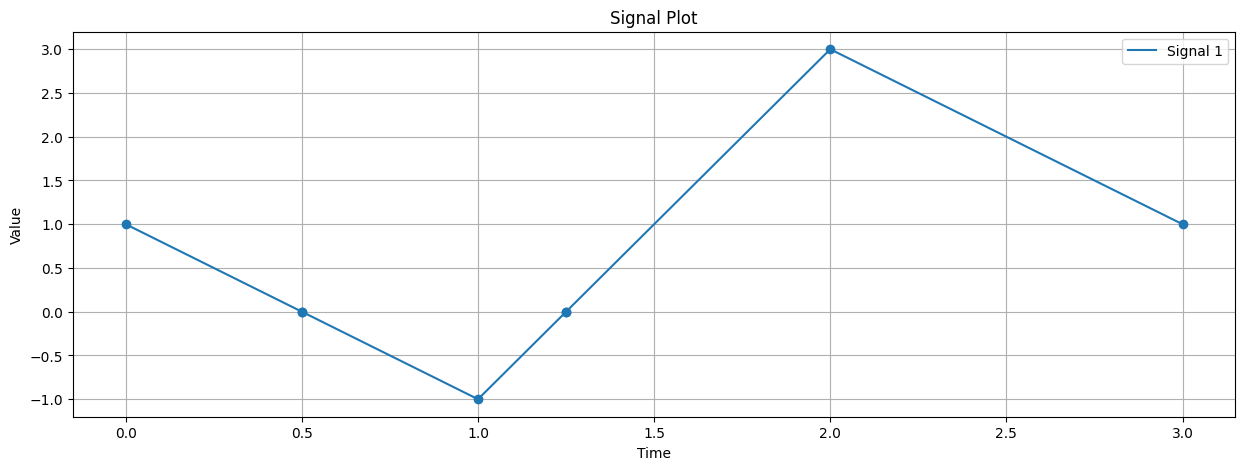

In [ ]:
mu_x.set_param("p", 0.5)
z = mu_x.eval_rob(0, 3)
z.plot()